In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

# Create all required project folders automatically inside your Google Drive
BASE_PATH = Path("/content/drive/MyDrive/dsa4060-week1-recommender")
(BASE_PATH / "data").mkdir(parents=True, exist_ok=True)
(BASE_PATH / "notebooks").mkdir(parents=True, exist_ok=True)
(BASE_PATH / "images").mkdir(parents=True, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


Dataset files not found. Downloading MovieLens dataset...
Dataset downloaded and organized successfully!
Movies shape: (9742, 3)
Ratings shape: (100836, 4)

Unique users: 610
Rated movies: 9724
Total interactions: 100836
Matrix Sparsity: 98.30%

--- Top 10 Popular Movies (Min 50 Ratings) ---


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000



--- Top 10 Movies by Weighted Rating ---


,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


<Figure size 1000x600 with 0 Axes>

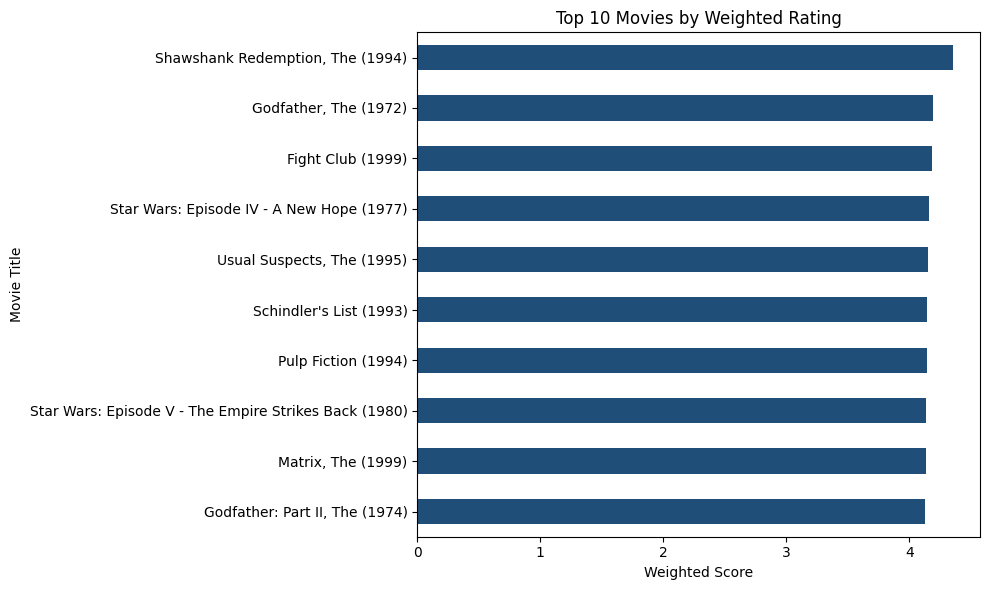


All tasks completed! Chart saved to images folder.


In [7]:
from pathlib import Path
import urllib.request
import zipfile
import matplotlib.pyplot as plt
import pandas as pd

# Define paths for Google Drive
BASE_PATH = Path("/content/drive/MyDrive/dsa4060-week1-recommender")
DATA_DIR = BASE_PATH / "data"
IMAGES_DIR = BASE_PATH / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

MOVIES_FILE = DATA_DIR / "movies.csv"
RATINGS_FILE = DATA_DIR / "ratings.csv"

# Automatically download and extract MovieLens dataset if files do not exist
if not MOVIES_FILE.exists() or not RATINGS_FILE.exists():
    print("Dataset files not found. Downloading MovieLens dataset...")
    zip_path = BASE_PATH / "ml-latest-small.zip"
    url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

    # Download zip file
    urllib.request.urlretrieve(url, zip_path)

    # Extract zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(BASE_PATH)

    # Find extracted CSV files and move them to data/
    extracted_dir = BASE_PATH / "ml-latest-small"
    if extracted_dir.exists():
        (extracted_dir / "movies.csv").replace(MOVIES_FILE)
        (extracted_dir / "ratings.csv").replace(RATINGS_FILE)
        # Clean up remaining files
        for f in extracted_dir.glob("*"):
            f.unlink()
        extracted_dir.rmdir()
    zip_path.unlink()
    print("Dataset downloaded and organized successfully!")

# --- Load and Inspect Dataset ---
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

# Summarize Ratings & Matrix Sparsity
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_interactions = len(ratings)

sparsity = 1 - (n_interactions / (n_users * n_movies_rated))
print(f"\nUnique users: {n_users}")
print(f"Rated movies: {n_movies_rated}")
print(f"Total interactions: {n_interactions}")
print(f"Matrix Sparsity: {sparsity:.2%}")

# --- Build Popularity Recommender ---
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count"),
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movieId", "title", "genres"]], on="movieId", how="left"
)


def recommend_popular_movies(stats, min_ratings=50, top_n=10):
  candidates = stats[stats["rating_count"] >= min_ratings].copy()
  return (
      candidates.sort_values(
          ["average_rating", "rating_count"], ascending=[False, False]
      )
      .head(top_n)[
          ["movieId", "title", "genres", "rating_count", "average_rating"]
      ]
  )


popular_recommendations = recommend_popular_movies(
    movie_stats, min_ratings=50, top_n=10
)
print("\n--- Top 10 Popular Movies (Min 50 Ratings) ---")
display(popular_recommendations)

# --- Weighted Rating Recommender (IMDb Formula) ---
C = ratings["rating"].mean()
m = movie_stats["rating_count"].quantile(0.90)

qualified = movie_stats[movie_stats["rating_count"] >= m].copy()
v = qualified["rating_count"]
R = qualified["average_rating"]

qualified["weighted_score"] = (v / (v + m)) * R + (m / (v + m)) * C

weighted_recommendations = qualified.sort_values(
    ["weighted_score", "rating_count"], ascending=[False, False]
).head(10)

print("\n--- Top 10 Movies by Weighted Rating ---")
display(
    weighted_recommendations[
        ["title", "genres", "rating_count", "average_rating", "weighted_score"]
    ]
)

# --- Plot & Save Visualization ---
plot_data = weighted_recommendations.sort_values("weighted_score")
plt.figure(figsize=(10, 6))
ax = plot_data.plot(
    x="title",
    y="weighted_score",
    kind="barh",
    figsize=(10, 6),
    color="#1F4E78",
    legend=False,
)
ax.set_title("Top 10 Movies by Weighted Rating")
ax.set_xlabel("Weighted Score")
ax.set_ylabel("Movie Title")
plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "top10_recommendations.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("\nAll tasks completed! Chart saved to images folder.")